Project: Demand Forecasting Platform

Goal: Predict player demand for upcoming games based on genre, reviews, launch month, marketing signals, franchise history.

Data Sources: 
- SteamCharts Top Games: daily peak players, monthly averages, historical player count per game
- Steam API: price, genre, release date, tags, supported platforms
- SteamSpy: estimated owners, reviews, playtime, genre popularity

In [40]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import time
from bs4 import BeautifulSoup
from tqdm import tqdm



In [41]:
## ---- Helper Functions

def clean_player_count(x):
    if pd.isna(x):
        return np.nan
    return float(str(x).replace(",", "").strip())


def parse_owners_midpoint(owner_range):
    """
    Converts SteamSpy owners range like: '20,000,000 .. 50,000,000' into midpoint estimate.
    """
    if pd.isna(owner_range):
        return np.nan
    try:
        low, high = str(owner_range).replace(",", "").split(" .. ")
        return (float(low) + float(high)) / 2
    except:
        return np.nan

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

Step 1: Collect Data

In [42]:
## ---- Steam Charts Top Games
headers = {"User-Agent": "Mozilla/5.0"}

def get_top_games(pages=4):
    all_games = []

    for page in range(1, pages + 1):
        url = "https://steamcharts.com/top" if page == 1 else f"https://steamcharts.com/top/p.{page}"
        html = requests.get(url, headers=headers).text

        df = pd.read_html(StringIO(html))[0]

        soup = BeautifulSoup(html, "html.parser")
        app_links = soup.select("td.game-name a[href^='/app/']")

        app_ids = []
        for link in app_links:
            app_id = link["href"].split("/app/")[1].split("/")[0]
            app_ids.append(app_id)

        df["app_id"] = app_ids
        all_games.append(df)

        time.sleep(1)

    return pd.concat(all_games, ignore_index=True)


def get_monthly_history(app_id, game_name, months=36):
    url = f"https://steamcharts.com/app/{app_id}"
    html = requests.get(url, headers=headers).text

    tables = pd.read_html(StringIO(html))
    history = tables[0]

    history["app_id"] = app_id
    history["game_name"] = game_name

    # remove "Last 30 Days" row, keep real months only
    history = history[history["Month"] != "Last 30 Days"]

    return history.head(months)


top_games = get_top_games(pages=4)

all_history = []

for _, row in top_games.iterrows():
    app_id = row["app_id"]
    game_name = row["Name"]

    print(f"Downloading {game_name} ({app_id})...")

    try:
        history = get_monthly_history(app_id, game_name, months=36)
        all_history.append(history)
    except Exception as e:
        print(f"Failed for {game_name}: {e}")

    time.sleep(1)

monthly_history_df = pd.concat(all_history, ignore_index=True)

#top_games.to_csv("steam_top_100_games.csv", index=False)
#monthly_history_df.to_csv("steam_top_100_monthly_history.csv", index=False)

print(top_games.shape)
print(monthly_history_df.shape)
print(monthly_history_df.head())

(100, 7)
(2859, 7)
           Month  Avg. Players       Gain  % Gain  Peak Players app_id  \
0     April 2026     974785.71  -94387.41  -8.83%       1564830    730   
1     March 2026    1069173.12  -14921.47  -1.38%       1717624    730   
2  February 2026    1084094.59   13650.81  +1.28%       1627561    730   
3   January 2026    1070443.78   79266.89  +8.00%       1654355    730   
4  December 2025     991176.89    9694.44  +0.99%       1620137    730   

          game_name  
0  Counter-Strike 2  
1  Counter-Strike 2  
2  Counter-Strike 2  
3  Counter-Strike 2  
4  Counter-Strike 2  


In [43]:
## ---- Data Collection Functions from Steam API and Steam Spy 
def get_store_details(app_id):
    url = "https://store.steampowered.com/api/appdetails"
    params = {
        "appids": app_id,
        "cc": "us",
        "l": "english"
    }

    r = requests.get(url, params=params, timeout=20)
    data = r.json()

    if not data[str(app_id)]["success"]:
        return None

    return data[str(app_id)]["data"]


def get_steamspy_details(app_id):
    url = "https://steamspy.com/api.php"
    params = {
        "request": "appdetails",
        "appid": app_id
    }

    r = requests.get(url, params=params, timeout=20)
    return r.json()

In [44]:
## ---- Data Collection from Steam API and Steam Spy 
metadata_rows = []

unique_games = top_games[["app_id", "Name"]].drop_duplicates()

for _, row in tqdm(unique_games.iterrows(), total=len(unique_games)):
    app_id = row["app_id"]
    game_name = row["Name"]

    try:
        store = get_store_details(app_id)
        spy = get_steamspy_details(app_id)

        if store is None:
            continue

        price = store.get("price_overview", {})

        metadata_rows.append({
            "app_id": app_id,
            "game_name": game_name,

            # --- Core features ---
            "release_date": store.get("release_date", {}).get("date"),
            "is_free": store.get("is_free"),

            # --- Pricing ---
            "initial_price": price.get("initial", 0) / 100 if price else 0,

            # --- Categories ---
            "genres": ", ".join([g["description"] for g in store.get("genres", [])]),
            "categories": ", ".join([c["description"] for c in store.get("categories", [])]),

            # --- Tags (from SteamSpy) ---
            "tags": ", ".join(spy.get("tags", {}).keys()) if spy.get("tags") else None,

            # --- Platforms ---
            "windows": store.get("platforms", {}).get("windows"),
            "mac": store.get("platforms", {}).get("mac"),
            "linux": store.get("platforms", {}).get("linux"),
            
            # Owners (string range like "20,000,000 .. 50,000,000")
            "owners": spy.get("owners"),

            # Engagement
            "avg_playtime_forever": spy.get("average_forever"),
            "avg_playtime_2weeks": spy.get("average_2weeks"),

            # Reviews
            "positive_reviews": spy.get("positive"),
            "negative_reviews": spy.get("negative"),
            
            # --- Extra useful signal ---
            "metacritic_score": store.get("metacritic", {}).get("score"),
        })

        time.sleep(1.2)

    except Exception as e:
        print(f"Metadata failed for {game_name}: {e}")

metadata_df = pd.DataFrame(metadata_rows)

def parse_owners(x):
    try:
        low, high = x.replace(",", "").split(" .. ")
        return (int(low) + int(high)) / 2
    except:
        return None

metadata_df["owners_estimate"] = metadata_df["owners"].apply(parse_owners)

def parse_owner_bounds(x):
    try:
        low, high = x.replace(",", "").split(" .. ")
        return pd.Series([int(low), int(high)])
    except:
        return pd.Series([np.nan, np.nan])

metadata_df[["owners_low", "owners_high"]] = metadata_df["owners"].apply(parse_owner_bounds)

metadata_df["total_reviews"] = (
    metadata_df["positive_reviews"] + metadata_df["negative_reviews"]
)

print(metadata_df.shape)
print(metadata_df.head())

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:35<00:00,  1.56s/it]

(99, 21)
    app_id            game_name  release_date  is_free  initial_price  \
0      730     Counter-Strike 2  Aug 21, 2012     True            0.0   
1      570               Dota 2   Jul 9, 2013     True            0.0   
2   578080  PUBG: BATTLEGROUNDS  Dec 21, 2017     True            0.0   
3  2676230                FiveM                  False            0.0   
4  3419430            Bongo Cat   Mar 5, 2025     True            0.0   

                                              genres  \
0                               Action, Free To Play   
1                     Action, Strategy, Free To Play   
2  Action, Adventure, Massively Multiplayer, Free...   
3                                                      
4  Casual, Indie, Massively Multiplayer, Simulati...   

                                          categories  \
0  Multi-player, Cross-Platform Multiplayer, Stea...   
1  Multi-player, Co-op, Steam Trading Cards, Stea...   
2  Multi-player, PvP, Online PvP, Custom Volume

In [45]:
## ---- Sanity Check: AppID comparisons
monthly_ids = set(monthly_history_df["app_id"].unique())
metadata_ids = set(metadata_df["app_id"].unique())

#In both
common_ids = monthly_ids & metadata_ids
print(f"Common app_ids: {len(common_ids)}")

#Only in MetaData
metadata_only = metadata_ids - monthly_ids
print(f"Only in metadata: {len(metadata_only)}")
print(metadata_only)

#Only in Monthly
monthly_only = monthly_ids - metadata_ids
print(f"Only in monthly: {len(monthly_only)}")
print(monthly_only)

Common app_ids: 97
Only in metadata: 2
{'3105440', '3124540'}
Only in monthly: 1
{'480'}


In [46]:
#Drop Edge case Rows -> Not in both Metadata and Monthly data
metadata_df = metadata_df[
    metadata_df["app_id"].isin(monthly_ids)
]

monthly_history_df = monthly_history_df[
    monthly_history_df["app_id"].isin(metadata_ids)
]

Step 2: Clean Data

In [47]:
## ---- Data Cleaning: 

## Monthly Data Clean: 
monthly_history_df = monthly_history_df.copy()

monthly_history_df["Month"] = pd.to_datetime(
    monthly_history_df["Month"],
    errors="coerce"
)

monthly_history_df["Avg. Players"] = monthly_history_df["Avg. Players"].apply(clean_player_count)
monthly_history_df["Peak Players"] = monthly_history_df["Peak Players"].apply(clean_player_count)

monthly_history_df = monthly_history_df.dropna(subset=["Month", "Avg. Players"])

monthly_history_df = monthly_history_df.sort_values(["app_id", "Month"])

## MetaData Clean

metadata_df = metadata_df.copy()

metadata_df["owners_estimate"] = metadata_df["owners"].apply(parse_owners_midpoint)

metadata_df["release_date_clean"] = pd.to_datetime(
    metadata_df["release_date"],
    errors="coerce"
)

metadata_df["release_year"] = metadata_df["release_date_clean"].dt.year

for col in ["tags", "genres", "categories"]:
    metadata_df[col] = metadata_df[col].fillna("")

metadata_df["is_free"] = metadata_df["is_free"].fillna(False).astype(int)

for col in [ "avg_playtime_forever",
            "avg_playtime_2weeks", "positive_reviews", "negative_reviews",
            "owners_estimate"]:
    metadata_df[col] = pd.to_numeric(metadata_df[col], errors="coerce").fillna(0)


/var/folders/t5/kyqptz75323dr0pw01ylcsmw0000gp/T/ipykernel_15366/2062705209.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_history_df["Month"] = pd.to_datetime(


Step 3: Label Data (Supervised Model) 

In [48]:
## ---- Given past data → predict next month players

#Create the label
monthly_history_df["target_next_month_avg_players"] = (
    monthly_history_df
    .groupby("app_id")["Avg. Players"]
    .shift(-1)
)

#Drop the last month (for training)
monthly_history_df = monthly_history_df.dropna(
    subset=["target_next_month_avg_players"]
)

Step 4: Choose and Create Features

In [49]:
# Merge Metadata (features) with monthly history (time series)
df = monthly_history_df.merge(
    metadata_df,
    on="app_id",
    how="left"
)

df = df.sort_values(["app_id", "Month"])

## ---- Identify time based features: 

# Lag features
for lag in [1, 2, 3, 6]:
    df[f"lag_{lag}"] = df.groupby("app_id")["Avg. Players"].shift(lag)

# Rolling features — correctly grouped by game
for window in [3, 6]:
    df[f"rolling_mean_{window}"] = (
        df.groupby("app_id")["Avg. Players"]
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

# Momentum features
df["growth_1"] = df.groupby("app_id")["Avg. Players"].pct_change(1)
df["growth_3"] = df.groupby("app_id")["Avg. Players"].pct_change(3)

# Replace inf values caused by divide-by-zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Time features
df["month_num"] = df["Month"].dt.month
df["year"] = df["Month"].dt.year
df["quarter"] = df["Month"].dt.quarter

df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

# Game age
df["game_age_months"] = (
    (df["Month"] - df["release_date_clean"]).dt.days / 30
)

df["game_age_months"] = df["game_age_months"].clip(lower=0)

# Metadata features
df["num_tags"] = df["tags"].apply(lambda x: len(x.split(", ")) if x else 0)
df["num_genres"] = df["genres"].apply(lambda x: len(x.split(", ")) if x else 0)

# Log lag features
for col in ["lag_1", "lag_2", "lag_3", "lag_6", "rolling_mean_3", "rolling_mean_6"]:
    df[f"log_{col}"] = np.log1p(df[col])

#Added features to reduce volatitlity after running 1st time
# 1. Spike detection
df["recent_spike"] = df["Avg. Players"] / df["rolling_mean_6"]

# 2. Distance from peak (lifecycle stage)
df["drop_from_peak"] = df["Avg. Players"] / df.groupby("app_id")["Avg. Players"].cummax()

# 3. Volatility
df["volatility_3"] = (
    df.groupby("app_id")["Avg. Players"]
    .transform(lambda x: x.shift(1).rolling(3).std())
)

# 4. Acceleration (trend change)
df["growth_acceleration"] = df["growth_1"] - df["growth_3"]

features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "growth_1",
    "growth_3",
    "month_num",
    "quarter",
    "year",
    "month_sin",
    "month_cos",
    "game_age_months",
    "is_free",
    "num_tags",
    "num_genres",
    "log_lag_1",
    "log_lag_2",
    "log_lag_3",
    "log_lag_6",
    "log_rolling_mean_3",
    "log_rolling_mean_6",
    "recent_spike",
    "drop_from_peak",
    "volatility_3",
    "growth_acceleration"
]

df_model = df.dropna(subset=features + ["target_next_month_avg_players"]).copy()

print(df_model.shape)

(2169, 56)


Step 5: Train Model -> Using Regression/Batch Gradient Descent For Time Series

In [50]:
df_model["target_month"] = df_model.groupby("app_id")["Month"].shift(-1)

train_df = df_model[df_model["target_month"] < "2025-01-01"]
test_df = df_model[df_model["target_month"] >= "2025-01-01"]

X_train = train_df[features]
X_test = test_df[features]

y_train_actual = train_df["target_next_month_avg_players"]
y_test_actual = test_df["target_next_month_avg_players"]

# Log target
y_train_log = np.log1p(y_train_actual)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 904
Test rows: 1178


In [51]:
baseline_preds = test_df["lag_1"]

baseline_results = {
    "Model": "Baseline: Last Month",
    "MAE": mean_absolute_error(y_test_actual, baseline_preds),
    "RMSE": rmse(y_test_actual, baseline_preds),
    "MAPE": mape(y_test_actual, baseline_preds)
}

baseline_results

{'Model': 'Baseline: Last Month',
 'MAE': 7328.073938879456,
 'RMSE': np.float64(14972.042377601112),
 'MAPE': np.float64(19.046486796877964)}

In [52]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )
}

results = [baseline_results]

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train_log)

    preds_log = model.predict(X_test)

    # Convert back to original player-count scale
    preds = np.expm1(preds_log)

    # Avoid negative predictions
    preds = np.maximum(preds, 0)

    predictions[name] = preds

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_actual, preds),
        "RMSE": rmse(y_test_actual, preds),
        "MAPE": mape(y_test_actual, preds)
    })

results_df = pd.DataFrame(results).sort_values("MAPE")
results_df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4902
[LightGBM] [Info] Number of data points in the train set: 904, number of used features: 27
[LightGBM] [Info] Start training from score 10.188105


,Model,MAE,RMSE,MAPE
2,Random Forest,6906.814248,19713.043518,14.400675
3,XGBoost,7474.278752,22090.659242,14.410131
4,LightGBM,8477.105529,29765.477360,15.018982
1,Linear Regression,8482.852650,30789.637459,15.865861
0,Baseline: Last Month,7328.073939,14972.042378,19.046487


Step 6: Evaluate

In [53]:
baseline_mape = results_df.loc[
    results_df["Model"] == "Baseline: Last Month", 
    "MAPE"
].values[0]

results_df["MAPE Improvement vs Baseline"] = (
    (baseline_mape - results_df["MAPE"]) / baseline_mape * 100
)

results_df

,Model,MAE,RMSE,MAPE,MAPE Improvement vs Baseline
2,Random Forest,6906.814248,19713.043518,14.400675,24.391964
3,XGBoost,7474.278752,22090.659242,14.410131,24.342317
4,LightGBM,8477.105529,29765.477360,15.018982,21.145658
1,Linear Regression,8482.852650,30789.637459,15.865861,16.699276
0,Baseline: Last Month,7328.073939,14972.042378,19.046487,0.000000


In [56]:
best_model_name = "Random Forest"
best_model = models[best_model_name]

importance_df = pd.DataFrame({
    "feature": features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
0,lag_1,0.217942
17,log_lag_1,0.214886
21,log_rolling_mean_3,0.196493
4,rolling_mean_3,0.194552
1,lag_2,0.033977
5,rolling_mean_6,0.029550
22,log_rolling_mean_6,0.028862
18,log_lag_2,0.018937
6,growth_1,0.016608
2,lag_3,0.006844


In [57]:
best_preds = predictions[best_model_name]

comparison_df = test_df[[
    "game_name_x",
    "Month",
    "Avg. Players",
    "target_next_month_avg_players"
]].copy()

comparison_df["predicted_next_month_avg_players"] = best_preds
comparison_df["absolute_error"] = (
    comparison_df["target_next_month_avg_players"] -
    comparison_df["predicted_next_month_avg_players"]
).abs()

comparison_df["percent_error"] = (
    comparison_df["absolute_error"] /
    comparison_df["target_next_month_avg_players"]
) * 100

comparison_df.sort_values("percent_error").head(20)

,game_name_x,Month,Avg. Players,target_next_month_avg_players,predicted_next_month_avg_players,absolute_error,percent_error
2688,Valheim,2026-01-01,22867.51,22465.83,22465.680833,0.149167,0.000664
656,STALCRAFT: X,2025-05-01,7807.65,9217.02,9217.605787,0.585787,0.006355
1136,ARK: Survival Ascended,2025-04-01,16600.82,15703.90,15701.269750,2.630250,0.016749
893,DayZ,2025-04-01,36205.95,35310.29,35319.560692,9.270692,0.026255
1231,The Binding of Isaac: Rebirth,2026-01-01,21632.94,20277.82,20283.199230,5.379230,0.026528
1302,Rust,2026-02-01,122376.91,106569.94,106602.286123,32.346123,0.030352
2277,Team Fortress 2,2026-01-01,48842.04,49577.86,49560.320607,17.539393,0.035377
983,Farming Simulator 25,2026-01-01,24155.85,23232.20,23220.608531,11.591469,0.049894
2203,Wallpaper Engine,2025-09-01,78471.64,83689.76,83731.787689,42.027689,0.050218
2020,Squad,2025-04-01,11421.65,13841.55,13834.083379,7.466621,0.053944


In [58]:
comparison_df.sort_values("percent_error", ascending=False).head(10)

,game_name_x,Month,Avg. Players,target_next_month_avg_players,predicted_next_month_avg_players,absolute_error,percent_error
1177,Counter-Strike: Source,2025-10-01,21027.17,10546.80,26062.792974,15515.992974,147.115646
1048,Diablo® IV,2026-01-01,11456.58,6328.43,14971.765944,8643.335944,136.579467
1038,Diablo® IV,2025-03-01,6844.32,5920.04,13035.471919,7115.431919,120.192295
1176,Counter-Strike: Source,2025-09-01,40279.19,21027.17,42178.323350,21151.153350,100.589634
332,Enshrouded,2025-06-01,10111.84,7130.78,14288.486126,7157.706126,100.377604
2405,HELLDIVERS™ 2,2025-10-01,29525.67,22073.53,42950.589307,20877.059307,94.579613
1040,Diablo® IV,2025-05-01,15384.41,6858.77,13277.620344,6418.850344,93.586027
1171,Counter-Strike: Source,2025-04-01,8010.87,7369.48,13879.467381,6509.987381,88.337133
855,PAYDAY 2,2025-01-01,24913.62,10920.73,20136.291241,9215.561241,84.385945
1045,Diablo® IV,2025-10-01,16193.51,6892.39,12679.747727,5787.357727,83.967357


Step 7: Analysis

In [59]:
import matplotlib.pyplot as plt

# Use the final comparison dataframe from your best model predictions
insights_df = comparison_df.copy()

# Ensure dates are datetime
insights_df["Month"] = pd.to_datetime(insights_df["Month"])

In [60]:
## ---- Overall Model Performance Summary


print("MODEL PERFORMANCE SUMMARY")
display(results_df)

best_row = results_df.sort_values("MAPE").iloc[0]
baseline_row = results_df[results_df["Model"].str.contains("Baseline", case=False)].iloc[0]

print(f"Best model: {best_row['Model']}")
print(f"Best model MAPE: {best_row['MAPE']:.2f}%")
print(f"Baseline MAPE: {baseline_row['MAPE']:.2f}%")
print(f"MAPE improvement vs baseline: {((baseline_row['MAPE'] - best_row['MAPE']) / baseline_row['MAPE']) * 100:.2f}%")

MODEL PERFORMANCE SUMMARY


,Model,MAE,RMSE,MAPE,MAPE Improvement vs Baseline
2,Random Forest,6906.814248,19713.043518,14.400675,24.391964
3,XGBoost,7474.278752,22090.659242,14.410131,24.342317
4,LightGBM,8477.105529,29765.477360,15.018982,21.145658
1,Linear Regression,8482.852650,30789.637459,15.865861,16.699276
0,Baseline: Last Month,7328.073939,14972.042378,19.046487,0.000000


Best model: Random Forest
Best model MAPE: 14.40%
Baseline MAPE: 19.05%
MAPE improvement vs baseline: 24.39%


HIGHEST ERROR PREDICTIONS


,game_name_x,Month,Avg. Players,target_next_month_avg_players,predicted_next_month_avg_players,absolute_error,percent_error
1177,Counter-Strike: Source,2025-10-01,21027.17,10546.80,26062.792974,15515.992974,147.115646
1048,Diablo® IV,2026-01-01,11456.58,6328.43,14971.765944,8643.335944,136.579467
1038,Diablo® IV,2025-03-01,6844.32,5920.04,13035.471919,7115.431919,120.192295
1176,Counter-Strike: Source,2025-09-01,40279.19,21027.17,42178.323350,21151.153350,100.589634
332,Enshrouded,2025-06-01,10111.84,7130.78,14288.486126,7157.706126,100.377604
2405,HELLDIVERS™ 2,2025-10-01,29525.67,22073.53,42950.589307,20877.059307,94.579613
1040,Diablo® IV,2025-05-01,15384.41,6858.77,13277.620344,6418.850344,93.586027
1171,Counter-Strike: Source,2025-04-01,8010.87,7369.48,13879.467381,6509.987381,88.337133
855,PAYDAY 2,2025-01-01,24913.62,10920.73,20136.291241,9215.561241,84.385945
1045,Diablo® IV,2025-10-01,16193.51,6892.39,12679.747727,5787.357727,83.967357


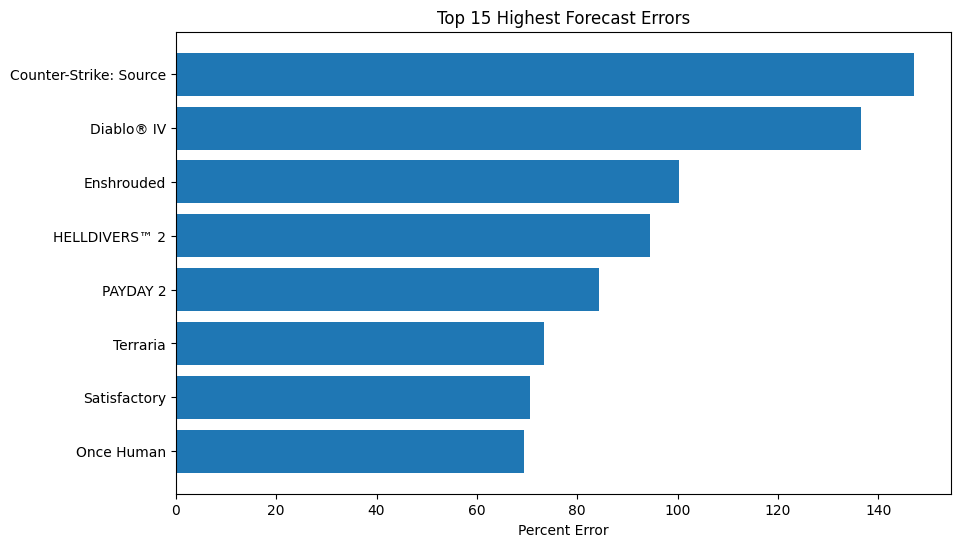

In [61]:
## ---- Which games had the highest forecast errors?

print("HIGHEST ERROR PREDICTIONS")

highest_error = (
    insights_df
    .sort_values("percent_error", ascending=False)
    .head(15)
)

display(highest_error[[
    "game_name_x",
    "Month",
    "Avg. Players",
    "target_next_month_avg_players",
    "predicted_next_month_avg_players",
    "absolute_error",
    "percent_error"
]])

plt.figure(figsize=(10, 6))
plt.barh(
    highest_error["game_name_x"],
    highest_error["percent_error"]
)
plt.xlabel("Percent Error")
plt.title("Top 15 Highest Forecast Errors")
plt.gca().invert_yaxis()
plt.show()

ERROR DIRECTION SUMMARY


,error_direction,percent_of_predictions
0,Overpredicted,53.989813
1,Underpredicted,46.010187


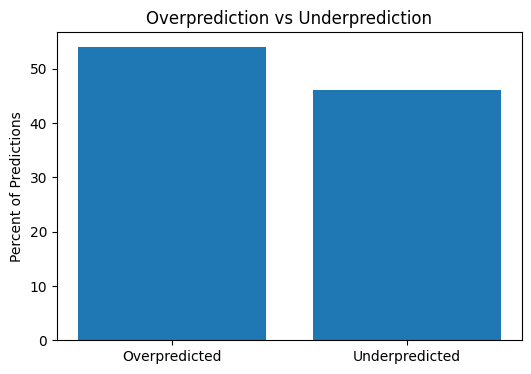

In [62]:
## ---- Is the model systematically overpredicting or underpredicting?

insights_df["prediction_error"] = (
    insights_df["predicted_next_month_avg_players"] -
    insights_df["target_next_month_avg_players"]
)

insights_df["error_direction"] = np.where(
    insights_df["prediction_error"] > 0,
    "Overpredicted",
    "Underpredicted"
)

print("ERROR DIRECTION SUMMARY")

error_direction_summary = (
    insights_df["error_direction"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

error_direction_summary.columns = ["error_direction", "percent_of_predictions"]

display(error_direction_summary)

plt.figure(figsize=(6, 4))
plt.bar(
    error_direction_summary["error_direction"],
    error_direction_summary["percent_of_predictions"]
)
plt.ylabel("Percent of Predictions")
plt.title("Overprediction vs Underprediction")
plt.show()

ERROR BY VOLATILITY BUCKET


,volatility_bucket,avg_percent_error,median_percent_error,avg_absolute_error,count
0,Low Volatility,11.638345,8.390513,2304.700611,393
1,Medium Volatility,14.475643,9.183936,3845.612831,392
2,High Volatility,17.088227,12.855096,14562.339985,393


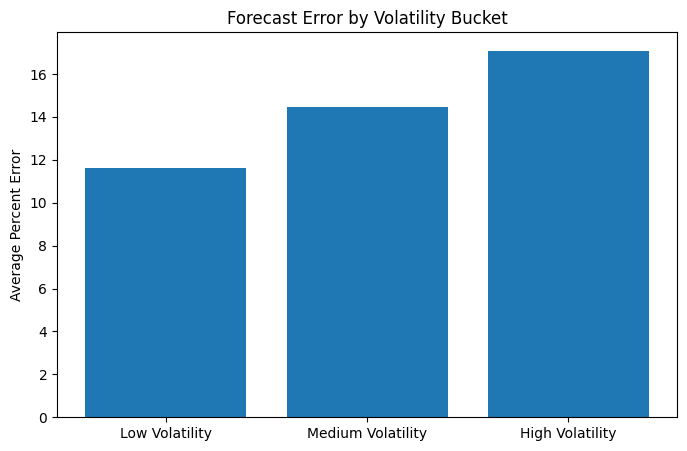

In [63]:
## ---- Does error increase for volatile games?

# Attach volatility features from df_model if not already in comparison_df
volatility_cols = [
    "game_name_x",
    "Month",
    "volatility_3",
    "recent_spike",
    "drop_from_peak",
    "growth_acceleration"
]

available_vol_cols = [col for col in volatility_cols if col in df_model.columns]

error_analysis_df = insights_df.merge(
    df_model[available_vol_cols],
    on=["game_name_x", "Month"],
    how="left"
)

error_analysis_df = error_analysis_df.dropna(subset=["volatility_3"])

error_analysis_df["volatility_bucket"] = pd.qcut(
    error_analysis_df["volatility_3"],
    q=3,
    labels=["Low Volatility", "Medium Volatility", "High Volatility"],
    duplicates="drop"
)

volatility_error_summary = (
    error_analysis_df
    .groupby("volatility_bucket", observed=True)
    .agg(
        avg_percent_error=("percent_error", "mean"),
        median_percent_error=("percent_error", "median"),
        avg_absolute_error=("absolute_error", "mean"),
        count=("game_name_x", "count")
    )
    .reset_index()
)

print("ERROR BY VOLATILITY BUCKET")
display(volatility_error_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    volatility_error_summary["volatility_bucket"].astype(str),
    volatility_error_summary["avg_percent_error"]
)
plt.ylabel("Average Percent Error")
plt.title("Forecast Error by Volatility Bucket")
plt.show()

TOP FEATURE IMPORTANCE / COEFFICIENTS


,feature,importance
0,lag_1,0.217942
17,log_lag_1,0.214886
21,log_rolling_mean_3,0.196493
4,rolling_mean_3,0.194552
1,lag_2,0.033977
5,rolling_mean_6,0.029550
22,log_rolling_mean_6,0.028862
18,log_lag_2,0.018937
6,growth_1,0.016608
2,lag_3,0.006844


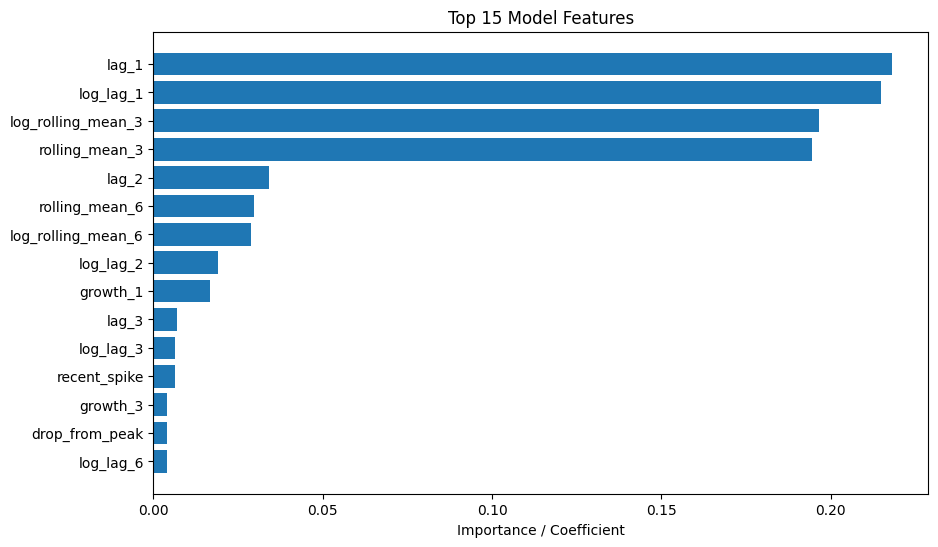

In [64]:
## ---- Which features mattered most?

print("TOP FEATURE IMPORTANCE / COEFFICIENTS")

display(importance_df.head(15))

top_features = importance_df.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.xlabel("Importance / Coefficient")
plt.title("Top 15 Model Features")
plt.gca().invert_yaxis()
plt.show()

FEATURE IMPORTANCE BY CATEGORY


,feature_category,total_importance,importance_share
2,Recent Player History,0.956038,95.603761
0,Momentum / Volatility,0.034817,3.481681
3,Seasonality,0.006609,0.660889
1,Other,0.002537,0.253668


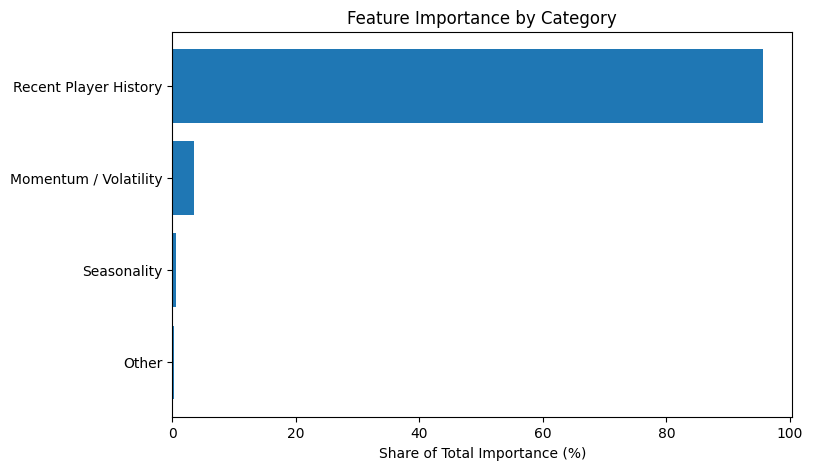

In [65]:
## ---- Group feature importance into categories

def classify_feature(feature):
    if any(x in feature for x in ["lag", "rolling"]):
        return "Recent Player History"
    elif any(x in feature for x in ["growth", "spike", "volatility", "peak"]):
        return "Momentum / Volatility"
    elif any(x in feature for x in ["month", "quarter", "year"]):
        return "Seasonality"
    elif any(x in feature for x in ["age"]):
        return "Lifecycle"
    else:
        return "Other"

feature_category_df = importance_df.copy()
feature_category_df["abs_importance"] = feature_category_df["importance"].abs()
feature_category_df["feature_category"] = feature_category_df["feature"].apply(classify_feature)

category_importance = (
    feature_category_df
    .groupby("feature_category")
    .agg(total_importance=("abs_importance", "sum"))
    .reset_index()
    .sort_values("total_importance", ascending=False)
)

category_importance["importance_share"] = (
    category_importance["total_importance"] /
    category_importance["total_importance"].sum()
) * 100

print("FEATURE IMPORTANCE BY CATEGORY")
display(category_importance)

plt.figure(figsize=(8, 5))
plt.barh(
    category_importance["feature_category"],
    category_importance["importance_share"]
)
plt.xlabel("Share of Total Importance (%)")
plt.title("Feature Importance by Category")
plt.gca().invert_yaxis()
plt.show()

ERROR BY RECENT SPIKE BUCKET


,spike_bucket,avg_percent_error,median_percent_error,count
0,Low Spike,16.812474,11.347579,393
1,Medium Spike,11.226592,7.504110,392
2,High Spike,15.154881,10.826102,393


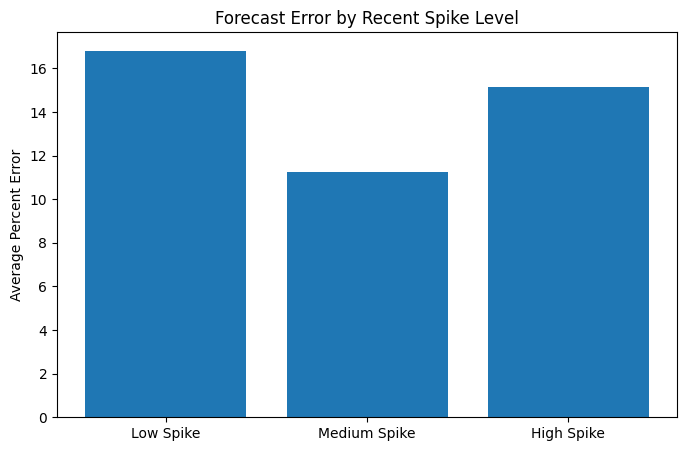

In [66]:
## ---- Are high-spike games harder to forecast?

if "recent_spike" in error_analysis_df.columns:
    spike_df = error_analysis_df.dropna(subset=["recent_spike"]).copy()

    spike_df["spike_bucket"] = pd.qcut(
        spike_df["recent_spike"],
        q=3,
        labels=["Low Spike", "Medium Spike", "High Spike"],
        duplicates="drop"
    )

    spike_error_summary = (
        spike_df
        .groupby("spike_bucket", observed=True)
        .agg(
            avg_percent_error=("percent_error", "mean"),
            median_percent_error=("percent_error", "median"),
            count=("game_name_x", "count")
        )
        .reset_index()
    )

    print("ERROR BY RECENT SPIKE BUCKET")
    display(spike_error_summary)

    plt.figure(figsize=(8, 5))
    plt.bar(
        spike_error_summary["spike_bucket"].astype(str),
        spike_error_summary["avg_percent_error"]
    )
    plt.ylabel("Average Percent Error")
    plt.title("Forecast Error by Recent Spike Level")
    plt.show()

GROWTH BY LIFECYCLE POSITION


,peak_bucket,avg_growth,median_growth,count
0,Far Below Peak,-0.036174,-0.049798,537
1,Below Peak,-0.034539,-0.037930,536
2,Near Peak,0.012065,-0.011106,536
3,At/Close to Peak,0.112170,0.057613,537


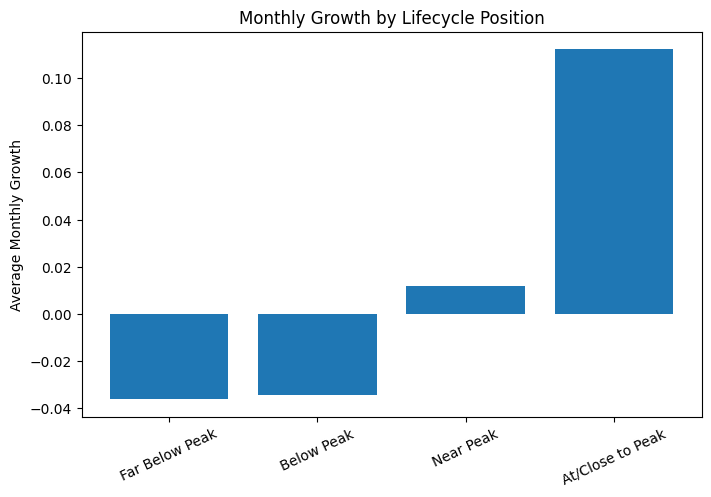

In [67]:
## ---- Does lifecycle position explain growth?

lifecycle_df = df_model.copy()

if "drop_from_peak" in lifecycle_df.columns and "growth_1" in lifecycle_df.columns:
    lifecycle_df = lifecycle_df[
        lifecycle_df["growth_1"].between(-1, 1)
    ].copy()

    lifecycle_df["peak_bucket"] = pd.qcut(
        lifecycle_df["drop_from_peak"],
        q=4,
        labels=["Far Below Peak", "Below Peak", "Near Peak", "At/Close to Peak"],
        duplicates="drop"
    )

    lifecycle_summary = (
        lifecycle_df
        .groupby("peak_bucket", observed=True)
        .agg(
            avg_growth=("growth_1", "mean"),
            median_growth=("growth_1", "median"),
            count=("game_name_x", "count")
        )
        .reset_index()
    )

    print("GROWTH BY LIFECYCLE POSITION")
    display(lifecycle_summary)

    plt.figure(figsize=(8, 5))
    plt.bar(
        lifecycle_summary["peak_bucket"].astype(str),
        lifecycle_summary["avg_growth"]
    )
    plt.ylabel("Average Monthly Growth")
    plt.title("Monthly Growth by Lifecycle Position")
    plt.xticks(rotation=25)
    plt.show()

In [68]:
## ---- Final takeaway helper table

summary_metrics = {
    "Best Model": best_row["Model"],
    "Best MAPE": f"{best_row['MAPE']:.2f}%",
    "Baseline MAPE": f"{baseline_row['MAPE']:.2f}%",
    "Improvement vs Baseline": f"{((baseline_row['MAPE'] - best_row['MAPE']) / baseline_row['MAPE']) * 100:.2f}%",
    "Highest Error Game": highest_error.iloc[0]["game_name_x"],
    "Highest Error %": f"{highest_error.iloc[0]['percent_error']:.2f}%"
}

summary_metrics_df = pd.DataFrame(
    summary_metrics.items(),
    columns=["Metric", "Value"]
)

print("FINAL SUMMARY METRICS")
display(summary_metrics_df)

FINAL SUMMARY METRICS


,Metric,Value
0,Best Model,Random Forest
1,Best MAPE,14.40%
2,Baseline MAPE,19.05%
3,Improvement vs Baseline,24.39%
4,Highest Error Game,Counter-Strike: Source
5,Highest Error %,147.12%


1. Overall Model Performance
The best-performing model was Random Forest, achieving a MAPE of 14.40%, compared to a baseline MAPE of 19.05%.
This represents a 24.39% improvement over baseline, showing that incorporating time-series features significantly improves forecasting accuracy.
- Time-series modeling provides meaningful predictive lift over naive baselines for player demand forecasting.

2. Demand is Strongly Driven by Recent Player Activity
Feature importance shows that ~95%+ of model importance comes from recent player history (lag and rolling features).
- Top features: lag_1, log_lag_1, rolling_mean_3, log_rolling_mean_3
- Momentum, lifecycle, and volatility features contribute very little relative signal.
- Player demand is highly autocorrelated — recent engagement is by far the strongest predictor of future demand.

3. Forecasting Performs Best for Stable Games
- Low-volatility games have an average error of ~11.7%
- Medium-volatility games: ~14.5%
- High-volatility games: ~17.2%
- The model performs well on stable games but becomes less accurate as volatility increases.

4. Event-Driven Spikes Are the Primary Source of Error
- The highest error cases include:
Counter-Strike: Source (147% error)
Diablo IV
HELLDIVERS 2
Enshrouded
- These are all: event-driven games, update-driven spikes, viral or seasonal surges
- The model struggles with event-driven demand spikes, which are not captured by historical features.

5. Model Bias: Slight Overprediction
- ~54% of predictions are overestimates
- ~46% are underestimates
- The model shows a mild bias toward overprediction, consistent with difficulty capturing post-spike declines.

6. Volatility Drives Forecast Error
- Error increases consistently across volatility buckets:
- Low: ~11.7%
- Medium: ~14.5%
- High: ~17.2%
- Volatility is a key driver of prediction difficulty — more unstable games are significantly harder to forecast.

7. Spike Behavior is Non-Linear
- Error by spike level:
- Low spike: ~16.8%
- Medium spike: ~11.3%
- High spike: ~15.1%
- Therefore, Medium spikes are easier to predict Extreme spikes (low or high) are harder
- The relationship between spike intensity and error is non-linear — moderate changes are predictable, but extreme deviations are not.

8. Lifecycle Position Has Limited Predictive Power
- Average growth by lifecycle:
- Far below peak: ~ -3.5%
- Below peak: ~ -3.4%
- Near peak: ~ +1.2%
- At peak: ~ +11.2%
- Therefore, Growth increases near peak, Decline exists below peak BUT differences are relatively small
- Lifecycle stage provides some directional signal, but is not a strong standalone predictor of short-term growth.

FINAL SUMMARY
- Player demand is primarily driven by recent engagement patterns
- Forecasting works well for stable games, but struggles with high-volatility, event-driven titles
- Volatility and spikes are the main sources of prediction error
- Lifecycle and other derived features add limited incremental value
- External signals (updates, releases, marketing) are likely missing drivers